In [1]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Read the input file and check the data dimension

In [2]:
df = pd.read_csv("german_credit.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

In [3]:
# Comments from examiner:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable
df.head()

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [4]:
# splitting data into training and test set for independent attributes
from sklearn.model_selection import train_test_split

X =  df.drop("default", axis=1)
y =  df.pop("default")

train_set, test_set, train_labels, test_labels = train_test_split(X, y, test_size=0.50, random_state=7)
train_labels.shape
#train_set.info()

(500,)

In [5]:
# Lets build a Ensemble model but need to modify the dataset first

### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [6]:
# Print Shape of model data
train_set.shape

(500, 20)

In [7]:
# Check categorical variables:
train_set['account_check_status'].value_counts()

no checking account                                   197
< 0 DM                                                144
0 <= ... < 200 DM                                     128
>= 200 DM / salary assignments for at least 1 year     31
Name: account_check_status, dtype: int64

In [8]:
dummy_account_check_status = pd.get_dummies(train_set['account_check_status'])
dummy_account_check_status.columns = ['account_check_status - ' + str(col) for col in dummy_account_check_status.columns]
dummy_account_check_status.head()

,account_check_status - 0 <= ... < 200 DM,account_check_status - < 0 DM,account_check_status - >= 200 DM / salary assignments for at least 1 year,account_check_status - no checking account
262,0,1,0,0
457,0,1,0,0
82,0,0,0,1
563,1,0,0,0
407,0,1,0,0


In [9]:
train_set['credit_history'].value_counts()

existing credits paid back duly till now                       266
critical account/ other credits existing (not at this bank)    150
delay in paying off in the past                                 41
all credits at this bank paid back duly                         26
no credits taken/ all credits paid back duly                    17
Name: credit_history, dtype: int64

In [10]:
dummy_credit_history = pd.get_dummies(train_set['credit_history'])
dummy_credit_history.columns = ['credit_history - ' + str(col) for col in dummy_credit_history.columns]
dummy_credit_history.drop('credit_history - existing credits paid back duly till now', axis=1, inplace=True)
dummy_credit_history.head()

,credit_history - all credits at this bank paid back duly,credit_history - critical account/ other credits existing (not at this bank),credit_history - delay in paying off in the past,credit_history - no credits taken/ all credits paid back duly
262,0,1,0,0
457,0,0,0,0
82,0,0,0,0
563,0,0,0,0
407,0,0,0,0


In [11]:
train_set['purpose'].value_counts()

domestic appliances             143
car (new)                       107
radio/television                 96
business                         49
car (used)                       49
(vacation - does not exist?)     22
education                        14
repairs                           8
furniture/equipment               8
retraining                        4
Name: purpose, dtype: int64

In [12]:
dummy_purpose = pd.get_dummies(train_set['purpose'])
dummy_purpose.columns = ['purpose - ' + str(col) for col in dummy_purpose.columns]
dummy_purpose.head()

,purpose - (vacation - does not exist?),purpose - business,purpose - car (new),purpose - car (used),purpose - domestic appliances,purpose - education,purpose - furniture/equipment,purpose - radio/television,purpose - repairs,purpose - retraining
262,0,0,1,0,0,0,0,0,0,0
457,0,0,0,1,0,0,0,0,0,0
82,0,1,0,0,0,0,0,0,0,0
563,0,0,1,0,0,0,0,0,0,0
407,0,0,0,0,1,0,0,0,0,0


In [13]:
train_set['savings'].value_counts()

... < 100 DM                   317
unknown/ no savings account     86
100 <= ... < 500 DM             47
500 <= ... < 1000 DM            35
.. >= 1000 DM                   15
Name: savings, dtype: int64

In [14]:
dummy_savings = pd.get_dummies(train_set['savings'])
dummy_savings.columns = ['savings - ' + str(col) for col in dummy_savings.columns]
dummy_savings.drop('savings - ... < 100 DM', axis=1, inplace=True)
dummy_savings.head()

,savings - .. >= 1000 DM,savings - 100 <= ... < 500 DM,savings - 500 <= ... < 1000 DM,savings - unknown/ no savings account
262,0,0,0,0
457,0,0,0,0
82,0,1,0,0
563,0,0,0,1
407,0,0,0,0


In [15]:
train_set['present_emp_since'].value_counts()

1 <= ... < 4 years    172
.. >= 7 years         126
... < 1 year           89
4 <= ... < 7 years     84
unemployed             29
Name: present_emp_since, dtype: int64

In [16]:
dummy_present_emp_since = pd.get_dummies(train_set['present_emp_since'])
dummy_present_emp_since.columns = ['present_emp_since - ' + str(col) for col in dummy_present_emp_since.columns]
dummy_present_emp_since.drop('present_emp_since - 1 <= ... < 4 years', axis=1, inplace=True)
dummy_present_emp_since.head()

,present_emp_since - .. >= 7 years,present_emp_since - ... < 1 year,present_emp_since - 4 <= ... < 7 years,present_emp_since - unemployed
262,1,0,0,0
457,1,0,0,0
82,0,0,0,0
563,0,0,0,0
407,0,1,0,0


In [17]:
train_set['personal_status_sex'].value_counts()

male : single                          276
female : divorced/separated/married    148
male : married/widowed                  50
male : divorced/separated               26
Name: personal_status_sex, dtype: int64

In [18]:
dummy_personal_status_sex = pd.get_dummies(train_set['personal_status_sex'])
dummy_personal_status_sex.columns = ['personal_status_sex - ' + str(col) for col in dummy_personal_status_sex.columns]
dummy_personal_status_sex.drop('personal_status_sex - male : single', axis=1, inplace=True)
dummy_personal_status_sex.head()

,personal_status_sex - female : divorced/separated/married,personal_status_sex - male : divorced/separated,personal_status_sex - male : married/widowed
262,0,0,0
457,0,0,0
82,1,0,0
563,0,0,0
407,0,0,1


In [19]:
train_set['other_debtors'].value_counts()

none            456
co-applicant     23
guarantor        21
Name: other_debtors, dtype: int64

In [20]:
dummy_other_debtors = pd.get_dummies(train_set['other_debtors'])
dummy_other_debtors.columns = ['other_debtors - ' + str(col) for col in dummy_other_debtors.columns]
dummy_other_debtors.drop('other_debtors - none', axis=1, inplace=True)
dummy_other_debtors.head()

,other_debtors - co-applicant,other_debtors - guarantor
262,0,0
457,0,0
82,0,0
563,0,0
407,0,0


In [21]:
train_set['property'].value_counts()

if not A121/A122 : car or other, not in attribute 6                 172
real estate                                                         146
if not A121 : building society savings agreement/ life insurance    104
unknown / no property                                                78
Name: property, dtype: int64

In [22]:
dummy_property = pd.get_dummies(train_set['property'])
dummy_property.columns = ['property - ' + str(col) for col in dummy_property.columns]
dummy_property.head()

,property - if not A121 : building society savings agreement/ life insurance,"property - if not A121/A122 : car or other, not in attribute 6",property - real estate,property - unknown / no property
262,0,0,0,1
457,0,0,0,1
82,1,0,0,0
563,0,0,0,1
407,0,0,1,0


In [23]:
train_set['other_installment_plans'].value_counts()

none      410
bank       68
stores     22
Name: other_installment_plans, dtype: int64

In [24]:
dummy_other_installment_plans = pd.get_dummies(train_set['other_installment_plans'])
dummy_other_installment_plans.columns = ['other_installment_plans - ' + str(col) for col in dummy_other_installment_plans.columns]
dummy_other_installment_plans.drop('other_installment_plans - none', axis=1, inplace=True)
dummy_other_installment_plans.head()

,other_installment_plans - bank,other_installment_plans - stores
262,0,0
457,0,0
82,0,0
563,0,0
407,0,0


In [25]:
train_set['housing'].value_counts()

own         350
rent         92
for free     58
Name: housing, dtype: int64

In [26]:
dummy_housing = pd.get_dummies(train_set['housing'])
dummy_housing.columns = ['housing - ' + str(col) for col in dummy_housing.columns]
dummy_housing.drop('housing - own', axis=1, inplace=True)
dummy_housing.head()

,housing - for free,housing - rent
262,1,0
457,1,0
82,0,1
563,1,0
407,0,0


In [27]:
train_set['job'].value_counts()

skilled employee / official                                      315
unskilled - resident                                             100
management/ self-employed/ highly qualified employee/ officer     72
unemployed/ unskilled - non-resident                              13
Name: job, dtype: int64

In [28]:
dummy_job = pd.get_dummies(train_set['job'])
dummy_job.columns = ['job - ' + str(col) for col in dummy_job.columns]
dummy_job.drop('job - skilled employee / official', axis=1, inplace=True)
dummy_job.head()

,job - management/ self-employed/ highly qualified employee/ officer,job - unemployed/ unskilled - non-resident,job - unskilled - resident
262,1,0,0
457,0,0,0
82,0,0,1
563,0,0,0
407,0,0,0


In [29]:
train_set['telephone'].value_counts()

none                                         297
yes, registered under the customers name     203
Name: telephone, dtype: int64

In [30]:
dummy_telephone = pd.get_dummies(train_set['telephone'])
dummy_telephone.columns = ['telephone - ' + str(col) for col in dummy_telephone.columns]
dummy_telephone.drop('telephone - none', axis=1, inplace=True)
dummy_telephone.head()

,"telephone - yes, registered under the customers name"
262,1
457,1
82,0
563,1
407,0


In [31]:
train_set['foreign_worker'].value_counts()

yes    484
no      16
Name: foreign_worker, dtype: int64

In [32]:
dummy_foreign_worker = pd.get_dummies(train_set['foreign_worker'])
dummy_foreign_worker.columns = ['foreign_worker - ' + str(col) for col in dummy_foreign_worker.columns]
dummy_foreign_worker.drop('foreign_worker - yes', axis=1, inplace=True)
dummy_foreign_worker.head()

,foreign_worker - no
262,0
457,0
82,0
563,0
407,1


### Drop the original variables which are converted to dummy

In [33]:
train_set = pd.concat([train_set, dummy_account_check_status], axis=1)
train_set = train_set.drop('account_check_status', 1)
train_set = pd.concat([train_set, dummy_credit_history], axis=1)
train_set = train_set.drop('credit_history', 1)
train_set = pd.concat([train_set, dummy_purpose], axis=1)
train_set = train_set.drop('purpose', 1)
train_set = pd.concat([train_set, dummy_savings], axis=1)
train_set = train_set.drop('savings', 1)
train_set = pd.concat([train_set, dummy_present_emp_since], axis=1)
train_set = train_set.drop('present_emp_since', 1)
train_set = pd.concat([train_set, dummy_personal_status_sex], axis=1)
train_set = train_set.drop('personal_status_sex', 1)
train_set = pd.concat([train_set, dummy_other_debtors], axis=1)
train_set = train_set.drop('other_debtors', 1)
train_set = pd.concat([train_set, dummy_property], axis=1)
train_set = train_set.drop('property', 1)
train_set = pd.concat([train_set, dummy_other_installment_plans], axis=1)
train_set = train_set.drop('other_installment_plans', 1)
train_set = pd.concat([train_set, dummy_housing], axis=1)
train_set = train_set.drop('housing', 1)
train_set = pd.concat([train_set, dummy_job], axis=1)
train_set = train_set.drop('job', 1)
train_set = pd.concat([train_set, dummy_telephone], axis=1)
train_set = train_set.drop('telephone', 1)
train_set = pd.concat([train_set, dummy_foreign_worker], axis=1)
train_set = train_set.drop('foreign_worker', 1)
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 500 entries, 262 to 175
Data columns (total 51 columns):
duration_in_month                                                               500 non-null int64
credit_amount                                                                   500 non-null int64
installment_as_income_perc                                                      500 non-null int64
present_res_since                                                               500 non-null int64
age                                                                             500 non-null int64
credits_this_bank                                                               500 non-null int64
people_under_maintenance                                                        500 non-null int64
account_check_status - 0 <= ... < 200 DM                                        500 non-null uint8
account_check_status - < 0 DM                                                   500 non-null uint8
ac

### Check for highly correlated variables but don't required any treatment for this use case

In [34]:
def get_redundant_pairs(train_set):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = train_set.columns
    for i in range(0, train_set.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(train_set, n=5):
    au_corr = train_set.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(train_set)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print("Top Absolute Correlations")
top_corr = pd.DataFrame(data = get_top_abs_correlations(train_set, 10))
top_corr

Top Absolute Correlations


,,0
property - unknown / no property,housing - for free,0.808156
duration_in_month,credit_amount,0.669686
present_emp_since - unemployed,job - unemployed/ unskilled - non-resident,0.550908
credits_this_bank,credit_history - critical account/ other credits existing (not at this bank),0.540030
account_check_status - < 0 DM,account_check_status - no checking account,0.512824
account_check_status - 0 <= ... < 200 DM,account_check_status - no checking account,0.472983
"property - if not A121/A122 : car or other, not in attribute 6",property - real estate,0.465053
job - management/ self-employed/ highly qualified employee/ officer,"telephone - yes, registered under the customers name",0.414907
account_check_status - 0 <= ... < 200 DM,account_check_status - < 0 DM,0.373070
property - if not A121 : building society savings agreement/ life insurance,"property - if not A121/A122 : car or other, not in attribute 6",0.371105


### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [35]:
# splitting data into training and test set for independent attributes

X_samples =  train_set
y_samples =  train_labels
X_train, X_test, y_train, y_test = train_test_split(X_samples, y_samples, test_size=0.30, random_state=7)

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [36]:
from sklearn.ensemble import RandomForestClassifier 
Rf_model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion='entropy',random_state=9999 )
Rf_model.fit(X_train, y_train)

C:\Users\Jatin_Thakkar\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\ensemble\weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d


RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [37]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc

y_predict_Rf=Rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_predict_Rf)
print(cm)
Rf_acc=metrics.accuracy_score(y_test,y_predict_Rf)
print(Rf_acc)

[[96  7]
 [30 17]]
0.7533333333333333


### Q6 Show the list of the features importance( 1 Marks)

In [38]:
print(pd.Series(Rf_model.feature_importances_,index = list(X_samples)).sort_values(ascending=False).head(10))

credit_amount                                                0.130339
duration_in_month                                            0.092070
age                                                          0.087479
account_check_status - no checking account                   0.061310
installment_as_income_perc                                   0.040164
present_res_since                                            0.037496
account_check_status - < 0 DM                                0.028133
personal_status_sex - female : divorced/separated/married    0.021979
credits_this_bank                                            0.021113
savings - unknown/ no savings account                        0.020996
dtype: float64


### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [39]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn import model_selection

In [40]:
# Use below values
num_folds = 10
seed = 77

In [41]:
#Validate the Random Forest model build above using k fold

In [42]:
models = []
models.append(('RandomForest', Rf_model))

In [43]:
kfold = model_selection.StratifiedKFold(n_splits=num_folds,random_state=seed)
cv_results = model_selection.cross_val_score(Rf_model, X_samples, y_samples, cv=kfold, scoring="accuracy")
# Calculate Mean score
# Calculate score standard deviation using std()
msg = "%f (%f)" % (np.mean(cv_results), cv_results.std())
print("mean score and stdev:")
print(msg)
## boxplot algorithm comparison
#fig = plt.figure()
#fig.suptitle('K-fold validation: ' + scoring)
#ax = fig.add_subplot(111)
#plt.boxplot(cv_results)
#ax.set_xticklabels("RF")
#plt.show()

mean score and stdev:
0.731898 (0.040265)


# Q8 Print the confusion matrix( 1 Marks)

In [44]:
print(cm)

[[96  7]
 [30 17]]


# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [45]:
report = pd.DataFrame(data=[accuracy_score(y_test, y_predict_Rf), 
                            recall_score(y_test, y_predict_Rf),
                            precision_score(y_test, y_predict_Rf)], 
                      index=["accuracy", "recall", "precision"])
report.columns = ['score']
report

,score
accuracy,0.753333
recall,0.361702
precision,0.708333


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [46]:
#Hint: Use roc_curve
from sklearn.metrics import roc_curve, auc

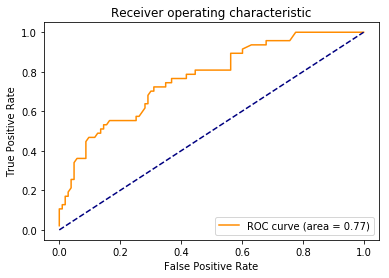

In [47]:
y_pred_prob = Rf_model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob[::,1])
roc_auc = auc(fpr, tpr)
roc_auc
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

In [48]:
print('AUC = %0.2f' % roc_auc)

AUC = 0.77


### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [49]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [50]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    Rf_model.fit(X_, y_)
    y_pred = Rf_model.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [51]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.724
Standard deviation:  0.02154065922853802
